# A Brief Introduction to Reinforcement Learning: From Tabular to Deep RL

This notebook explores the progression of Reinforcement Learning (RL) techniques, starting from simple discrete environments and moving towards complex continuous control problems using Deep Q-Learning. 

We will observe how the environment's complexity grows and discuss the benefits and challenges associated with different learning methods:
1. **Discrete Grid Environment**: Simple Tabular Q-learning.
2. **Continuous Environment (Simple Dynamics)**: Discretized Q-learning and resolution comparisons.
3. **Linear Function Approximation**: Comparing feature constructions (Tile Coding, Polynomial, Fourier) and discretized approaches.
4. **Momentum and Randomized Hole Locations**: Adding physical complexity and increasing environmental uncertainty and state-space dimensionality.
5. **Deep Q-Learning (DQN)**: Overcoming the "curse of dimensionality" with neural networks.



In [1]:
## IMPORTS ##
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# Local environment imports
from rosie_bonfire_env import RosieGridEnv
from rosie_continuous_env import RosieContinuousEnv
from rosie_momentum_env import RosieMomentumEnv
from rosie_momentum_random_holes_env import RosieMomentumRandomHolesEnv
from dqn_model import DQN, CNNDQN, ReplayBuffer

# Create directory for saving results if it doesn't exist
if not os.path.exists('saved_results'):
    os.makedirs('saved_results')

def save_result(obj, filename):
    with open(os.path.join('saved_results', filename), 'wb') as f:
        pickle.dump(obj, f)

def load_result(filename):
    path = os.path.join('saved_results', filename)
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None


## 1. Discrete Environment: Tabular Q-Learning

### Environment Complexity
In this first stage, the environment is a simple **10x10 grid**. Rosie moves between discrete cells (up, down, left, right). The state is perfectly represented by her grid coordinates $(x, y)$.

### Method: Tabular Q-Learning
- **The Update Equation**: 
  $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$
- **Benefits**: Guaranteed convergence to the optimal policy; simple to implement and interpret.
- **Challenges**: Does not scale to large or continuous state spaces (the table becomes too large).

### Reward Structure
| Event | Reward |
|---|---|
| Reach goal | $+1$ |
| Fall into a hole | $-10$ |
| Each step taken | $-1$ |

The step penalty encourages Rosie to find short paths; the asymmetric goal/hole rewards make avoiding holes the dominant priority.

No saved model found. Training from scratch...


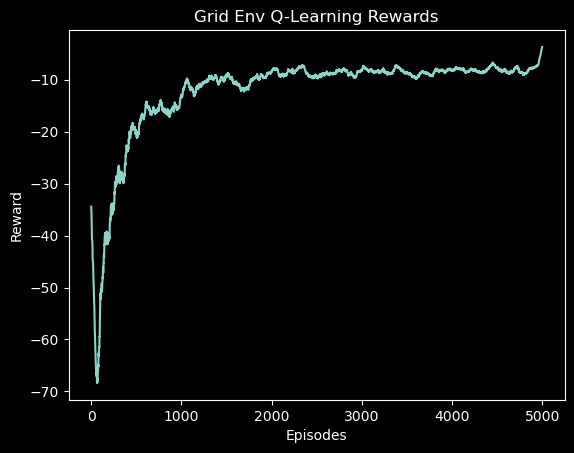

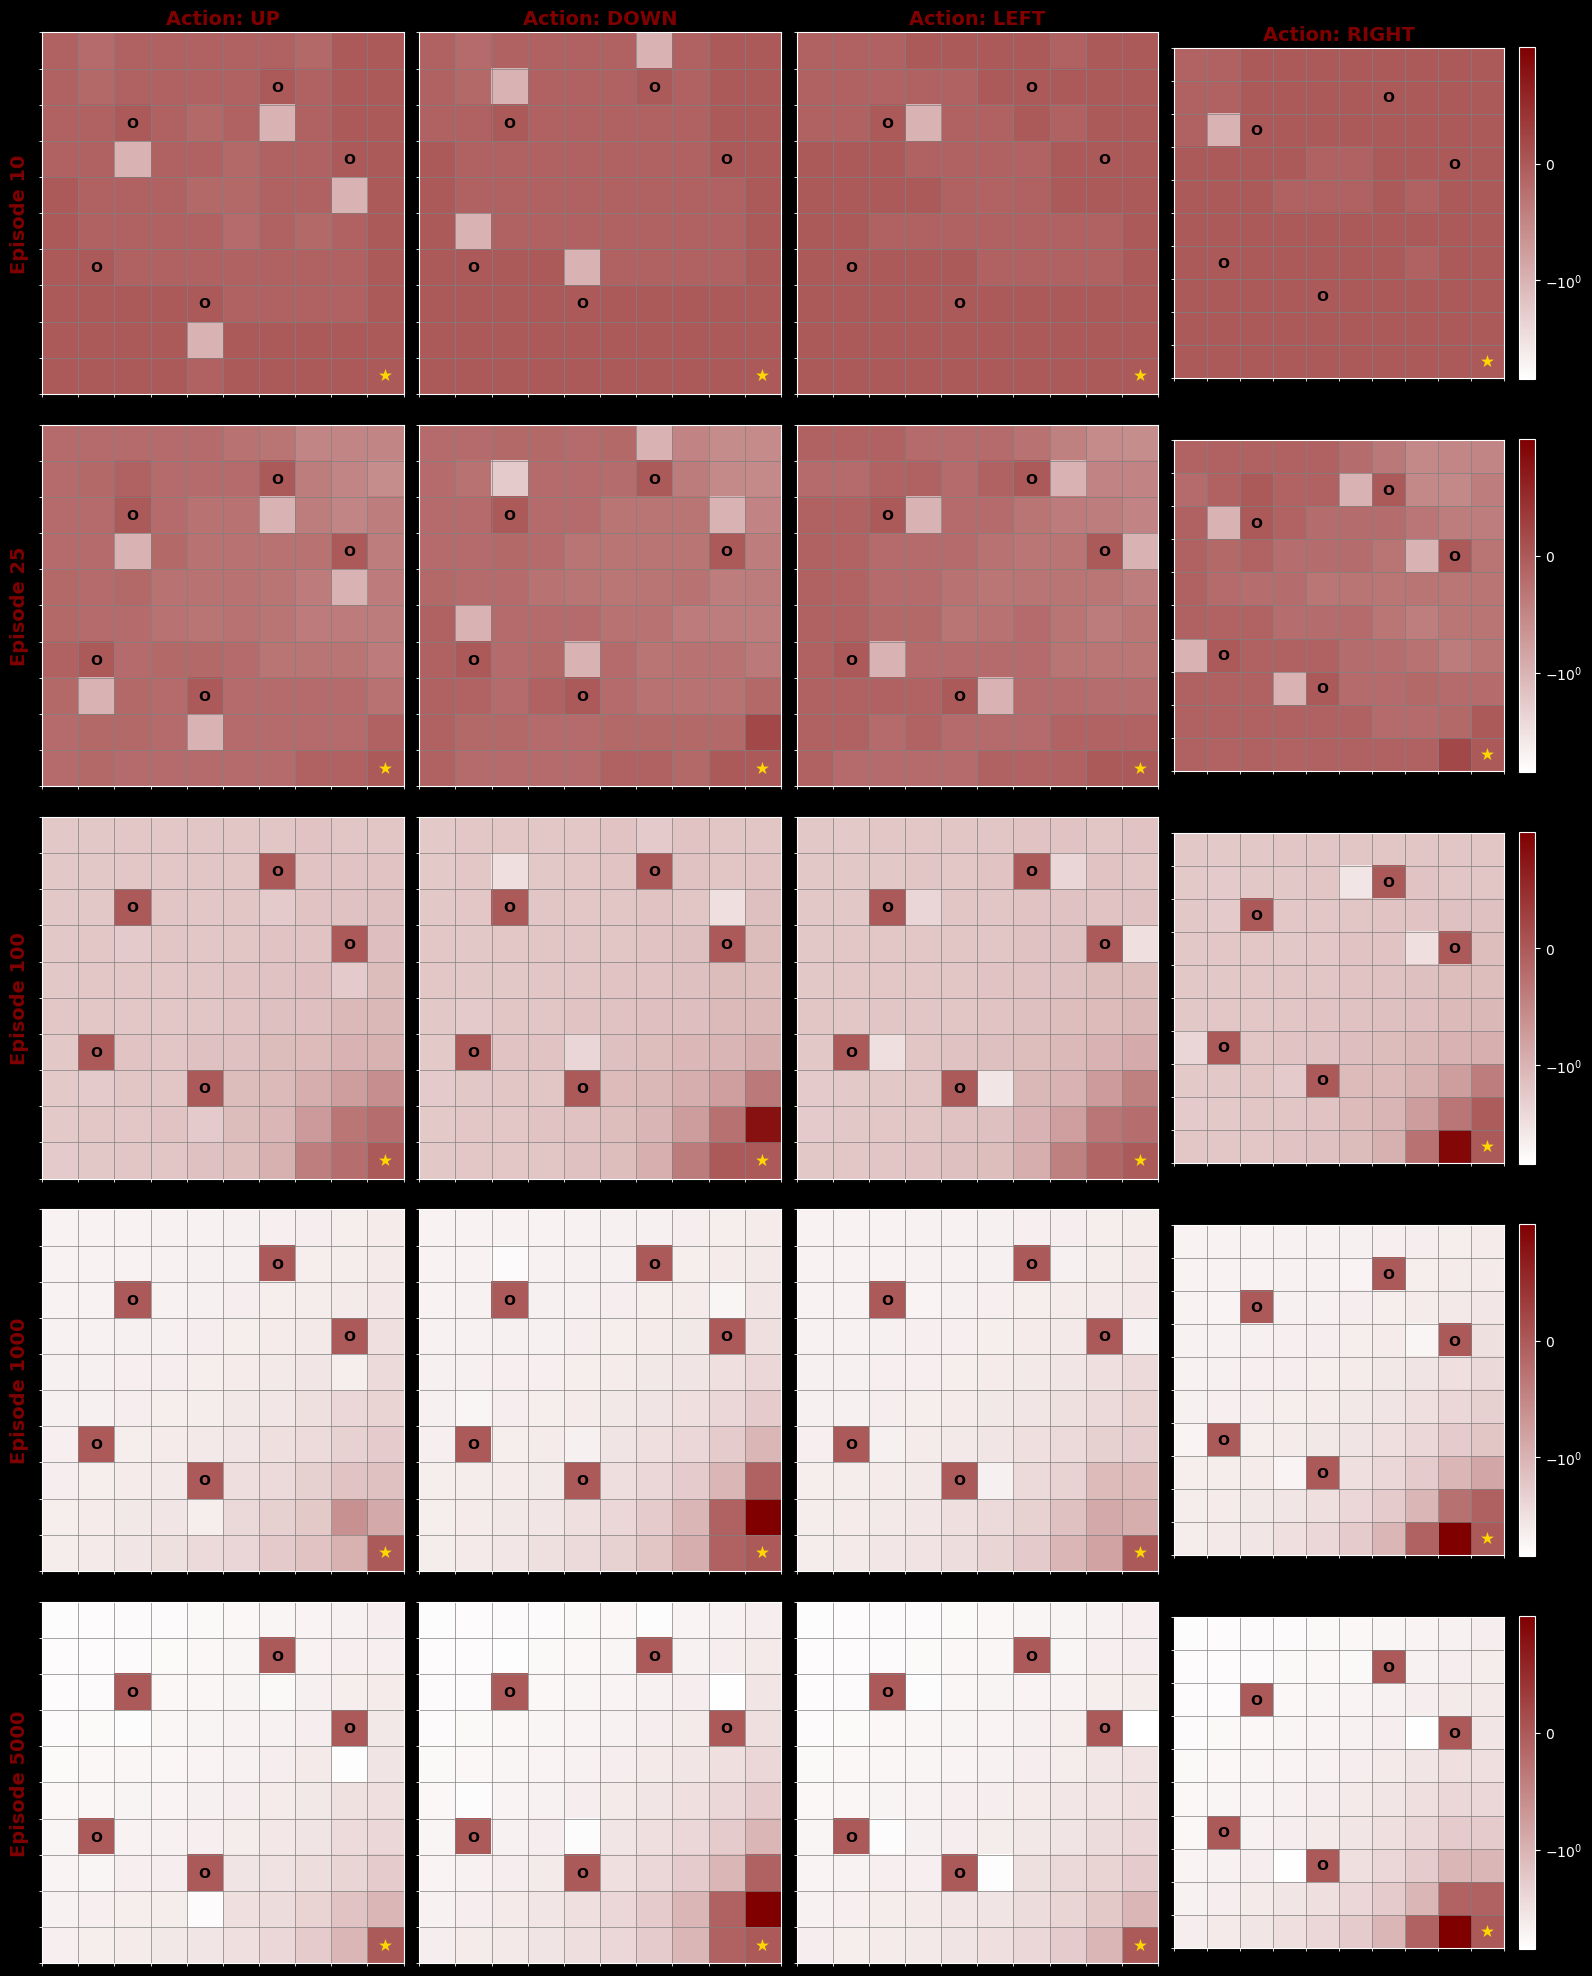

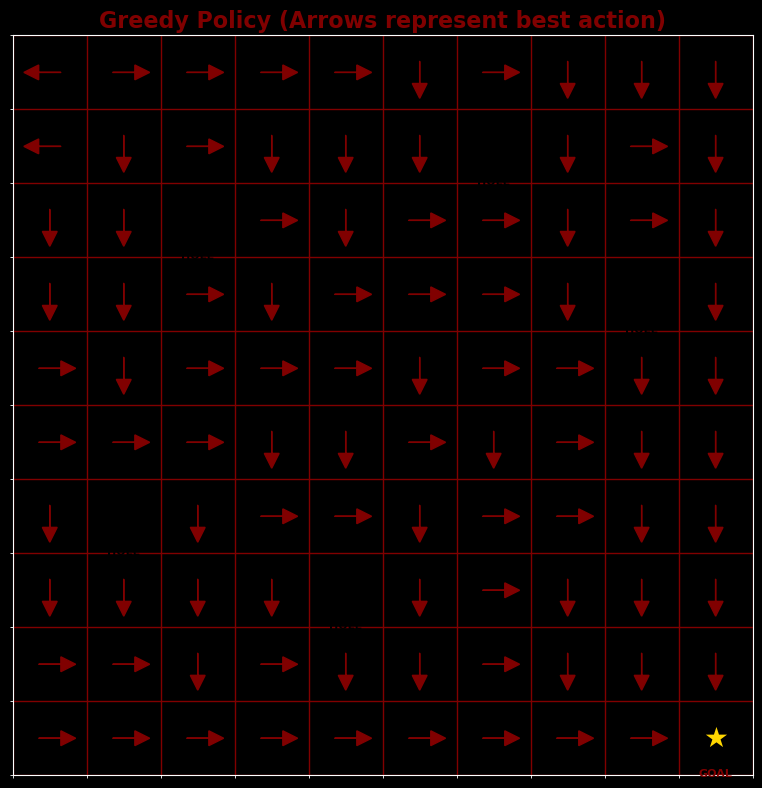

In [9]:
## Initialize environment, Q-Table and hyperparameters ##
env = RosieGridEnv(grid_size=10)

# Try to load existing Q-table and rewards
Q_table_grid = load_result('q_table_grid.pkl')
rewards_grid = load_result('rewards_grid.pkl')

if Q_table_grid is None or rewards_grid is None:
    print("No saved model found. Training from scratch...")
    Q_table_grid = np.zeros((env.grid_size, env.grid_size, len(env.action_space)))
    
    episode_count = 5000
    max_steps = 500
    gamma = 0.9
    epsilon = 0.1
    alpha = 0.1
    rewards_grid = np.zeros(episode_count)
    
    snapshot_episodes_target = {10, 25, 100, 1000}  # episode 5000 captured after the loop
    q_snapshots = []
    snapshot_episodes = []
    
    for e in range(episode_count):
        if e in snapshot_episodes_target:
            q_snapshots.append(Q_table_grid.copy())
            snapshot_episodes.append(e)

        ep_reward = 0
        env.reset()
        state = env.agent_pos
        for j in range(max_steps):
            # Choose action using epsilon-greedy policy
            if epsilon < np.random.rand():
                action = Q_table_grid[state[0], state[1]].argmax()
            else:
                action = np.random.randint(0, len(env.action_space))
            
            # Take action and observe results
            state_next, rew, done = env.step(action)
            ep_reward += float(rew)
        
            # Update Q-table using the Temporal Difference (TD) target: r + gamma * max Q(s', a')
            td_target = rew + gamma * np.max(Q_table_grid[state_next[0], state_next[1]])
            td_error = td_target - Q_table_grid[state[0], state[1]][action]
            Q_table_grid[state[0], state[1]][action] += alpha * td_error

            state = state_next
            if done: break
        rewards_grid[e] = ep_reward
    
    # Capture final snapshot at episode 5000
    q_snapshots.append(Q_table_grid.copy())
    snapshot_episodes.append(episode_count)
    
    save_result(Q_table_grid, 'q_table_grid.pkl')
    save_result(rewards_grid, 'rewards_grid.pkl')
    save_result((q_snapshots, snapshot_episodes), 'snapshots_grid.pkl')
else:
    print("Loaded saved Q-table and rewards.")
    q_snapshots, snapshot_episodes = load_result('snapshots_grid.pkl')
    rewards_grid = rewards_grid.flatten()
    print(f"Loaded {len(rewards_grid)} reward records.")

# Plot Rewards
plt.plot(np.convolve(rewards_grid, np.ones(100)/100, mode='same'))
plt.title("Grid Env Q-Learning Rewards")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

# Plot Q-value heatmaps across training snapshots
env.plot_q_table_progression(q_snapshots, snapshot_episodes)

# Plot the final greedy policy
env.plot_policy(Q_table_grid)

env.run_gui(q_table=Q_table_grid)


## 2. Continuous Environment: Discretized Q-Learning

### Environment Complexity
Rosie now moves in a **continuous 2D space** with inertia. Her state is $(x, y, v_x, v_y)$. This significantly increases the state space dimensionality from 2D to 4D, and each dimension is no longer discrete.

### Method: State Discretization
- **The Update Equation**: 
  $Q(\text{bin}(s), a) \leftarrow Q(\text{bin}(s), a) + \alpha [r + \gamma \max_{a'} Q(\text{bin}(s'), a') - Q(\text{bin}(s), a)]$
- **Benefits**: Allows us to reuse tabular methods by "binning" continuous values into discrete buckets.
- **Challenges**: The **Curse of Dimensionality**—as we add dimensions or increase resolution, the number of states grows exponentially. Too coarse a discretization fails to capture fine control; too fine a discretization takes too long to explore.

### Reward Structure
| Event | Reward |
|---|---|
| Reach goal (within goal radius) | $+100$ |
| Fall into a hole (within hole radius) | $-100$ |
| Each step taken | $-1$ |

The larger terminal rewards (compared to the grid environment) reflect the finer-grained continuous space — the agent must navigate more precisely, so the goal and hazard signals need to be proportionally stronger to drive learning.

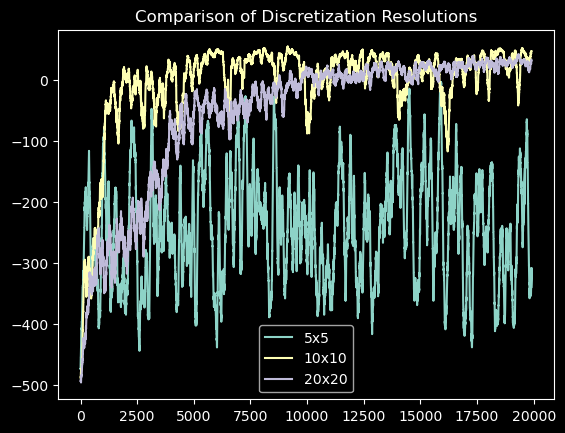

In [3]:
def discretize_state(state, n_bins_pos, n_bins_vel, grid_size=10.0, max_vel=5.0):
    x, y, vx, vy = state
    ix = int(np.clip(x / grid_size * n_bins_pos, 0, n_bins_pos - 1))
    iy = int(np.clip(y / grid_size * n_bins_pos, 0, n_bins_pos - 1))
    ivx = int(np.clip((vx + max_vel) / (2 * max_vel) * n_bins_vel, 0, n_bins_vel - 1))
    ivy = int(np.clip((vy + max_vel) / (2 * max_vel) * n_bins_vel, 0, n_bins_vel - 1))
    return (ix, iy, ivx, ivy)

def train_q_learning_continuous(n_bins_pos, n_bins_vel, episodes=10000):
    env = RosieContinuousEnv()
    q_table = np.zeros((n_bins_pos, n_bins_pos, n_bins_vel, n_bins_vel, len(env.action_space)))
    alpha, gamma, epsilon, max_steps = 0.1, 0.95, 0.1, 500
    history = []
    for e in range(episodes):
        state = env.reset()
        d_state = discretize_state(state, n_bins_pos, n_bins_vel)
        total_reward = 0
        for _ in range(max_steps):
            # Epsilon-greedy action selection
            action = np.random.randint(0, len(env.action_space)) if np.random.rand() < epsilon else np.argmax(q_table[d_state])
            
            # Step in environment
            next_state, reward, done = env.step(action)
            d_next = discretize_state(next_state, n_bins_pos, n_bins_vel)
            
            # Standard Tabular Q-update
            q_table[d_state][action] += alpha * (reward + gamma * np.max(q_table[d_next]) - q_table[d_state][action])
            
            d_state, total_reward = d_next, total_reward + reward
            if done: break
        history.append(total_reward)
    return q_table, history

resolutions = [(5, 3), (10, 5), (20, 7)]
results_cont = load_result('continuous_q_results.pkl')
q_tables_cont = load_result('continuous_q_tables.pkl')

if results_cont is None:
    results_cont, q_tables_cont = {}, {}
    for pos_res, vel_res in resolutions:
        print(f"Training resolution {pos_res}x{vel_res}...")
        q, h = train_q_learning_continuous(pos_res, vel_res)
        results_cont[f"{pos_res}x{pos_res}"] = h
        q_tables_cont[f"{pos_res}x{pos_res}"] = q
    save_result(results_cont, 'continuous_q_results.pkl')
    save_result(q_tables_cont, 'continuous_q_tables.pkl')

for label, history in results_cont.items():
    history = np.array(history).flatten()
    plt.plot(np.convolve(history, np.ones(100)/100, mode='valid'), label=label)
plt.title("Comparison of Discretization Resolutions"); plt.legend(); plt.show()


## 2b. Linear Function Approximation

### Method: Function Approximation
Instead of a table, we approximate $Q(s, a)$ as a linear combination of features: $Q(s, a; \mathbf{w}) = \mathbf{w}_a^\top \phi(s)$. 

- **The Update Equation (Semi-gradient SARSA)**:
  $\mathbf{w}_a \leftarrow \mathbf{w}_a + \alpha [r + \gamma Q(s', a'; \mathbf{w}) - Q(s, a; \mathbf{w})] \nabla_{\mathbf{w}_a} Q(s, a; \mathbf{w})$
  Since $Q(s, a; \mathbf{w}) = \mathbf{w}_a^\top \phi(s)$, the gradient is simply the feature vector: $\nabla_{\mathbf{w}_a} Q(s, a; \mathbf{w}) = \phi(s)$.

### Benefits and Challenges
- **Benefits**: Requires much less memory than a table; can generalize between similar states; enables learning in truly continuous spaces.
- **Challenges**: Performance depends heavily on the **choice of features** $\phi(s)$. If the features can't represent the optimal value function, the agent will never learn it.

### Reward Structure
This section uses the same continuous environment as Section 2.

| Event | Reward |
|---|---|
| Reach goal (within goal radius) | $+100$ |
| Fall into a hole (within hole radius) | $-100$ |
| Each step taken | $-1$ |

Because function approximation generalizes across states, the $\pm 100$ terminal rewards propagate more broadly through weight updates than they would in a table — a single goal experience can shift $Q$-values for many nearby states simultaneously.

## Feature Representations for Linear Function Approximation

Each of these methods defines a fixed feature map $\phi(s)$ — the choice determines what structure the approximator can represent, how efficiently it generalizes, and how quickly it breaks down as state dimensionality grows.

---

### Polynomial Features

**Advantages:**
- Intuitive and easy to implement — features are powers and cross-products of state variables (e.g., $x^2$, $xy$, $x^2y$)

$$\phi(s) = \left[1,\ x,\ y,\ x^2,\ xy,\ y^2,\ x^3,\ x^2y,\ xy^2,\ y^3,\ \ldots \right]^\top$$

- Smooth approximation; works well when the true value function is well-behaved and continuous
- Easy to control complexity by choosing the polynomial degree

**Disadvantages:**
- Scales poorly — a degree-$d$ polynomial over $n$ state dimensions produces $\mathcal{O}(n^d)$ features (curse of dimensionality)
- Global basis: changing one weight affects the approximation everywhere, so local errors propagate widely
- Can oscillate badly near state-space boundaries (Runge's phenomenon)

---

### Fourier Series Features

$$\phi(s) = \left[\cos(\pi \mathbf{c}_i^\top s)\right]_{i=1}^{n}$$

where each $\mathbf{c}_i = (c_1, c_2)^\top$ is a vector of integer frequency coefficients, giving:

$$\phi(s) = \left[\cos(\pi(c_1 x + c_2 y))\right]_{\forall\ c_1, c_2 \in \{0, 1, \ldots, n\}}$$

![My Image](Images/Fourier%20basis%20features.png)
![My Image](Images/Fourier%20typically%20outperforms%20Poly.png)
**Advantages:**
- Strong theoretical backing — any square-integrable function can be approximated arbitrarily well with enough terms
- Naturally captures periodic or oscillatory structure in the value function
- Performs well in low-to-moderate dimensional spaces with a modest number of terms

**Disadvantages:**
- Also a global basis, so local changes in the value function require adjustments across many coefficients
- Poor fit for non-periodic domains (which most RL environments are) — boundary effects degrade accuracy
- Feature count still grows exponentially with state dimension

---

### Tile Coding
$$\phi(s) = \left[\mathbf{1}\left[s \in T_{i,j}\right]\right]_{i=1,\ j=1}^{n_{\text{tilings}},\ n_{\text{tiles}}}$$

where $T_{i,j}$ is the $j$-th tile in the $i$-th tiling, and $\mathbf{1}[\cdot]$ is the indicator function.

![My Image](Images/tile%20coding.png)

Tiling offsets are chosen so that each tile covers a small fraction of the state space.

$$T_{i,j} \text{ is defined by grid } G \text{ shifted by offset } \delta_i = \frac{i}{n_{\text{tilings}} \cdot n_{\text{tiles}}}$$

![My Image](Images/tiling%20overlaps.png)

![My Image](Images/effect%20of%20tilings.png)

**Advantages:**
- Local generalization — each tile activates only for a small region of state space, so updates stay local
- Binary, sparse feature vectors make dot-product computation fast and memory-efficient
- Multiple overlapping tilings (offset from each other) provide smooth coverage without sacrificing locality
- Empirically robust across a wide range of RL tasks; the default recommendation in Sutton & Barto for linear FA

**Disadvantages:**
- Resolution is fixed at design time — bin widths must be chosen before training, and a poor choice is hard to correct
- Still suffers from the curse of dimensionality in high-dimensional spaces (the 7D random-holes environment is already near the practical limit)
    - 10^7 x 8 tiles is a LOT of tiles!
- Ignores interactions between distant state dimensions unless tilings are explicitly designed to capture them

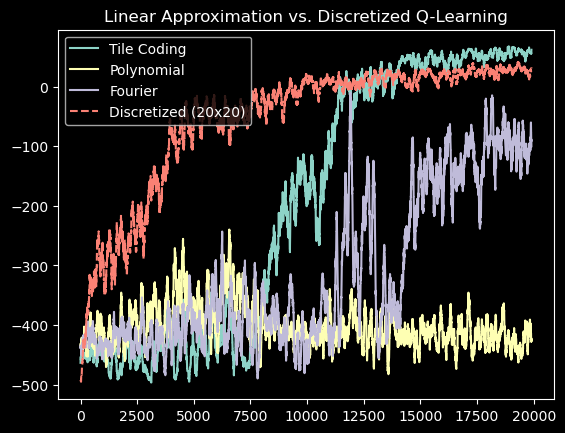

In [4]:
import itertools

def get_tile_features(state, n_tiles=8, n_tilings=8, grid_size=10.0, max_vel=5.0):
    x, y, vx, vy = state
    nx, ny, nvx, nvy = x/grid_size, y/grid_size, (vx+max_vel)/(2*max_vel), (vy+max_vel)/(2*max_vel)
    features = []
    for i in range(n_tilings):
        offset = i / (n_tiles * n_tilings)
        ix, iy = int(np.clip((nx+offset)*n_tiles, 0, n_tiles-1)), int(np.clip((ny+offset)*n_tiles, 0, n_tiles-1))
        ivx, ivy = int(np.clip((nvx+offset)*n_tiles, 0, n_tiles-1)), int(np.clip((nvy+offset)*n_tiles, 0, n_tiles-1))
        features.append(i * (n_tiles**4) + (ix + iy*n_tiles + ivx*(n_tiles**2) + ivy*(n_tiles**3)))
    return np.array(features)

def get_polynomial_features(state, order=4, grid_size=10.0, max_vel=5.0):
    x, y, vx, vy = state
    s = np.array([x/grid_size, y/grid_size, (vx+max_vel)/(2*max_vel), (vy+max_vel)/(2*max_vel)])
    features = [1.0]
    for o in range(1, order + 1):
        for combo in itertools.combinations_with_replacement(range(4), o):
            features.append(np.prod(s[list(combo)]))
    return np.array(features)

def get_fourier_features(state, order=5, grid_size=10.0, max_vel=5.0):
    x, y, vx, vy = state
    s = np.array([x/grid_size, y/grid_size, (vx+max_vel)/(2*max_vel), (vy+max_vel)/(2*max_vel)])
    if not hasattr(get_fourier_features, "coeffs"):
        get_fourier_features.coeffs = np.array([c for c in itertools.product(range(order + 1), repeat=4) if sum(c) <= order + 1])
    return np.cos(np.pi * np.dot(get_fourier_features.coeffs, s))

def train_linear_sarsa(feature_fn, f_size, is_sparse=True, episodes=20000, alpha_scale=0.1):
    env = RosieContinuousEnv(); n_actions = len(env.action_space)
    w = np.zeros((n_actions, f_size))
    gamma, lam, epsilon, eps_min = 0.95, 0.9, 1.0, 0.01
    history = []
    for e in range(episodes):
        state = env.reset(); feat = feature_fn(state); alpha = alpha_scale * (0.1 + 0.9 * (1 - e/episodes))
        # Get Q-values for all actions: Q(s, a) = w[a] * phi(s)
        q_vals = [np.sum(w[a, feat]) if is_sparse else np.dot(w[a], feat) for a in range(n_actions)]

        # Epsilon-greedy action selection
        action = np.random.randint(n_actions) if np.random.rand() < epsilon else np.argmax(q_vals)
        z = np.zeros((n_actions, f_size)); q_old, total_reward = q_vals[action], 0

        for _ in range(500):
            # Step environment
            next_state, reward, done = env.step(action); next_feat = feature_fn(next_state); total_reward += reward

            # Get Q-values for next state
            next_q = [np.sum(w[a, next_feat]) if is_sparse else np.dot(w[a], next_feat) for a in range(n_actions)]

            # Select next action (SARSA)
            next_act = np.random.randint(n_actions) if np.random.rand() < epsilon else np.argmax(next_q)

            # Calculate TD error: delta = r + gamma * Q(s', a') - Q(s, a)
            delta = reward + gamma * (0 if done else next_q[next_act]) - q_vals[action]

            # Eligibility trace update (True Online Sarsa(lambda))
            x_f = np.zeros(f_size); x_f[feat] = 1 if is_sparse else feat
            dot_z_x = np.sum(z[action, feat]) if is_sparse else np.dot(z[action], x_f)
            z[action] = gamma * lam * z[action] + (1 - alpha * gamma * lam * dot_z_x) * x_f

            # Weight update
            w += alpha * (delta + q_vals[action] - q_old) * z
            if is_sparse: w[action, feat] -= alpha * (q_vals[action] - q_old)
            else: w[action] -= alpha * (q_vals[action] - q_old) * x_f

            if done: break
            state, feat, action, q_vals, q_old = next_state, next_feat, next_act, next_q, next_q[next_act]
        epsilon = max(eps_min, epsilon * 0.9995); history.append(total_reward)
    return w, history

linear_results = load_result('linear_sarsa_results.pkl')
if linear_results is None:
    print("Training Linear Sarsa models...")
    w_t, h_t = train_linear_sarsa(lambda s: get_tile_features(s), 8 * (8**4), is_sparse=True, alpha_scale=0.2/8)
    print("Training Polynomial...")
    poly_feat_size = len(get_polynomial_features(np.zeros(4), 4))
    w_p, h_p = train_linear_sarsa(lambda s: get_polynomial_features(s, 4), poly_feat_size, is_sparse=False, alpha_scale=0.005)
    print("Training Fourier...")
    w_f, h_f = train_linear_sarsa(lambda s: get_fourier_features(s, order=5), len(get_fourier_features(np.zeros(4), 5)), is_sparse=False, alpha_scale=0.001)
    linear_results = {'tile': (w_t, h_t), 'poly': (w_p, h_p), 'fourier': (w_f, h_f)}
    save_result(linear_results, 'linear_sarsa_results.pkl')

# Unpack reward histories from (weights, history) tuples
h_tile = linear_results['tile'][1]
h_poly = linear_results['poly'][1]
h_fourier = linear_results['fourier'][1]
h_cont = results_cont['20x20']  # Discretized Q-learning (20x20 bins)

plt.plot(np.convolve(np.array(h_tile), np.ones(100)/100, mode='valid'), label="Tile Coding")
plt.plot(np.convolve(np.array(h_poly), np.ones(100)/100, mode='valid'), label="Polynomial")
plt.plot(np.convolve(np.array(h_fourier), np.ones(100)/100, mode='valid'), label="Fourier")
plt.plot(np.convolve(np.array(h_cont), np.ones(100)/100, mode='valid'), label="Discretized (20x20)", linestyle='--')
plt.title("Linear Approximation vs. Discretized Q-Learning")
plt.legend()
plt.show()

## 3. Momentum and Randomized Hole Locations

### Increase Environment Complexity

#### Momentum
We add a new hidden variable: **Water Mass**.
- Rosie's acceleration now depends on how much water she has left $$\frac{\operatorname{d}}{dt}\left({\vec{\mathbb{P}}}_{\mathrm{sys}}\right)=\sum_{\mathrm{in}}\dot{\vec{\mathbb{P}}}-\sum_{\mathrm{out}}\dot{\vec{\mathbb{P}}}$$
- Spraying water reduces her mass but changes her momentum.
- The state is now 5D: $(x, y, v_x, v_y, mass)$.
- Dynamics are non-linear, making the control problem much harder for simple discretization.

#### Random Hole Locations
Up until now, the "holes" (obstacles) were in fixed positions. Now, **holes are randomized every episode**. 
- To succeed, the agent can no longer memorize a path; it must learn to avoid obstacles based on their current relative positions. 
- The state grows to 7D: $(x, y, v_x, v_y, mass, \Delta x_{hole}, \Delta y_{hole})$. 
- Tabular Q-learning begins to fail here due to the enormous state space ($10^7$ states).

### Reward Structure
| Event | Reward                            |
|---|-----------------------------------|
| Reach goal | $+100 + 20 \times m_\text{water}$ |
| Fall into a hole | $-100$                            |
| Run out of water and stop | -$t$ to end   (terminal)          |
| Each step taken | $-1$                              |

The reward function now includes a water bonus to support efficiency. There an added challenge here is not in the reward signal but the **state space explosion**: the agent must now generalize across hole positions it has never seen, which is why tabular methods struggle even though the reward structure is minimally changed.

In [5]:
def discretize_random_holes_state(state, n_bins_pos=10, n_bins_vel=5, n_bins_water=5, n_bins_hole=10, grid_size=10.0, max_vel=2.0, max_water=25.0):
    x, y, vx, vy, water, dx_h, dy_h = state
    ix, iy = int(np.clip(x/grid_size*n_bins_pos, 0, n_bins_pos-1)), int(np.clip(y/grid_size*n_bins_pos, 0, n_bins_pos-1))
    ivx, ivy = int(np.clip((vx+max_vel)/(2*max_vel)*n_bins_vel, 0, n_bins_vel-1)), int(np.clip((vy+max_vel)/(2*max_vel)*n_bins_vel, 0, n_bins_vel-1))
    iw = int(np.clip(water/max_water*n_bins_water, 0, n_bins_water-1))
    idxh, idyh = int(np.clip((dx_h+grid_size)/(2*grid_size)*n_bins_hole, 0, n_bins_hole-1)), int(np.clip((dy_h+grid_size)/(2*grid_size)*n_bins_hole, 0, n_bins_hole-1))
    return (ix, iy, ivx, ivy, iw, idxh, idyh)

def train_random_holes_tabular(episodes=5000):
    env = RosieMomentumRandomHolesEnv(); q_shape = (10,10,5,5,5,10,10, len(env.action_space))
    Q = np.zeros(q_shape); alpha, gamma, epsilon = 0.1, 0.99, 0.1; history = []
    for e in range(episodes):
        state = env.reset(); d_s = discretize_random_holes_state(state); total_reward = 0
        while True:
            # Epsilon-greedy action selection
            action = np.random.randint(len(env.action_space)) if np.random.random() < epsilon else np.argmax(Q[d_s])
            
            # Step in environment
            next_s, reward, done = env.step(action); d_n = discretize_random_holes_state(next_s)
            
            # Tabular Q-update
            Q[d_s][action] += alpha * (reward + gamma * np.max(Q[d_n]) - Q[d_s][action])
            
            d_s, total_reward = d_n, total_reward + reward
            if done: break
        history.append(total_reward)
    return Q, history

random_holes_tab_res = load_result('random_holes_q_results.pkl')
if random_holes_tab_res is None:
    q_rh, h_rh = train_random_holes_tabular()
    save_result((q_rh, h_rh), 'random_holes_q_results.pkl')
else:
    q_rh, h_rh = random_holes_tab_res

#plt.plot(np.convolve(h_rh, np.ones(100)/100, mode='valid'))
#plt.title("Tabular Q-Learning with Randomized Holes"); plt.show()


## 3b. Linear Tile Coding SARSA on the Random Holes Environment

### Why Apply Function Approximation Here?
The 7D state space $(x, y, v_x, v_y, \text{mass}, \Delta x_\text{hole}, \Delta y_\text{hole})$ has far too many combinations for a tabular agent to visit all states. Tile coding generalizes across nearby states, meaning the agent can learn useful values for states it hasn't seen exactly before.

### Tile Coding on 7 Dimensions
Each of the 7 state dimensions is normalized to $[0, 1]$ and partitioned into $n_\text{tiles}$ bins. With $n_\text{tilings}$ overlapping tilings (each shifted by a small offset), the agent's current state activates exactly $n_\text{tilings}$ features — one per tiling. This sparse representation supports fast, stable updates.

- **Feature size**: $n_\text{tilings} \times n_\text{tiles}^7 = 8 \times 5^7 = 17{,}496$ — much smaller than the $10^7$ states a full tabular agent would need
- **Update rule**: Same True Online SARSA($\lambda$) as before; only the feature function changes

### Reward Structure
Same environment as Section 5 — reward function is unchanged.

| Event | Reward                            |
|---|-----------------------------------|
| Reach goal | $+100 + 20 \times m_\text{water}$ |
| Fall into a hole | $-100$                            |
| Run out of water and stop | -$t$ to end (terminal)            |
| Each step taken | $-1$                              |

Because tile coding generalizes within each tiling's bins, the water bonus encourages the agent to reach the goal with high water mass remaining — this is a useful shaping signal that helps distinguish near-optimal trajectories from merely adequate ones.

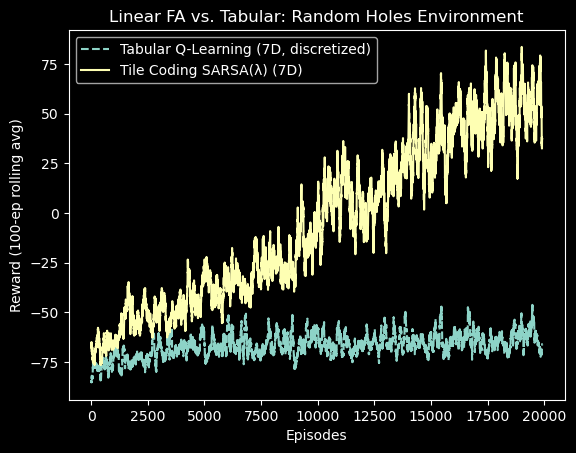

In [6]:
def get_random_holes_tile_features(state, n_tiles=3, n_tilings=8, grid_size=10.0, max_vel=5.0, max_water=25.0, max_hole_dist=10.0):
    x, y, vx, vy, water, dx_hole, dy_hole = state
    # Normalize all 7 dimensions to [0, 1]
    s = np.array([
        x / grid_size,
        y / grid_size,
        (vx + max_vel) / (2 * max_vel),
        (vy + max_vel) / (2 * max_vel),
        water / max_water,
        (dx_hole + max_hole_dist) / (2 * max_hole_dist),
        (dy_hole + max_hole_dist) / (2 * max_hole_dist),
    ])
    features = []
    for i in range(n_tilings):
        # Each tiling is offset slightly so they don't overlap perfectly
        offset = i / (n_tiles * n_tilings)
        indices = [int(np.clip((s[d] + offset) * n_tiles, 0, n_tiles - 1)) for d in range(7)]
        # Compute flat index: tiling block + position within block
        flat = i * (n_tiles ** 7) + sum(indices[d] * (n_tiles ** d) for d in range(7))
        features.append(flat)
    return np.array(features)

def train_linear_sarsa_random_holes(n_tiles=3, n_tilings=8, episodes=5000, alpha_scale=0.0125):
    env = RosieMomentumRandomHolesEnv()
    n_actions = len(env.action_space)
    feature_size = n_tilings * (n_tiles ** 7)  # = 8 * 3^7 = 17,496
    w = np.zeros((n_actions, feature_size))
    gamma, lam, epsilon, eps_min = 0.95, 0.9, 1.0, 0.05
    eps_decay = (eps_min / epsilon) ** (1 / episodes)
    history = []

    for e in range(episodes):
        state = env.reset()
        feat = get_random_holes_tile_features(state, n_tiles, n_tilings)
        alpha = alpha_scale * (0.1 + 0.9 * (1 - e / episodes))
        # Q(s, a) = sum of active tile weights (sparse dot product)
        q_vals = [np.sum(w[a, feat]) for a in range(n_actions)]
        action = np.random.randint(n_actions) if np.random.rand() < epsilon else np.argmax(q_vals)
        z = np.zeros((n_actions, feature_size))
        q_old, total_reward, done = q_vals[action], 0, False

        for _ in range(1000):
            next_state, reward, done = env.step(action)
            next_feat = get_random_holes_tile_features(next_state, n_tiles, n_tilings)
            total_reward += reward
            next_q = [np.sum(w[a, next_feat]) for a in range(n_actions)]
            next_action = np.random.randint(n_actions) if np.random.rand() < epsilon else np.argmax(next_q)

            # TD error
            delta = reward + gamma * (0 if done else next_q[next_action]) - q_vals[action]

            # True Online SARSA(lambda) eligibility trace update
            x_feat = np.zeros(feature_size); x_feat[feat] = 1
            dot_z_x = np.sum(z[action, feat])
            z[action] = gamma * lam * z[action] + (1 - alpha * gamma * lam * dot_z_x) * x_feat

            # Weight update
            w += alpha * (delta + q_vals[action] - q_old) * z
            w[action, feat] -= alpha * (q_vals[action] - q_old)

            if done: break
            state, feat, action, q_vals, q_old = next_state, next_feat, next_action, next_q, next_q[next_action]

        epsilon = max(eps_min, epsilon * eps_decay)
        history.append(total_reward)
        if e % 500 == 0:
            print(f"  Episode {e}, Avg Reward: {np.mean(history[-100:]):.2f}")

    return w, history

linear_rh_result = load_result('linear_sarsa_random_holes_results.pkl')
if linear_rh_result is None:
    print("Training Linear Tile Coding SARSA on Random Holes...")
    w_rh_linear, h_rh_linear = train_linear_sarsa_random_holes()
    linear_rh_result = (w_rh_linear, h_rh_linear)
    save_result(linear_rh_result, 'linear_sarsa_random_holes_results.pkl')
else:
    w_rh_linear, h_rh_linear = linear_rh_result

# Compare tile coding vs tabular on the same environment
plt.plot(np.convolve(h_rh, np.ones(100)/100, mode='valid'), label='Tabular Q-Learning (7D, discretized)', linestyle='--')
plt.plot(np.convolve(h_rh_linear, np.ones(100)/100, mode='valid'), label='Tile Coding SARSA(λ) (7D)')
plt.title("Linear FA vs. Tabular: Random Holes Environment")
plt.xlabel("Episodes"); plt.ylabel("Reward (100-ep rolling avg)")
plt.legend(); plt.show()

## 5. Deep Q-Learning (DQN) Comparison

### Method: Deep Q-Learning (DQN)
DQN replaces the Q-table with a **Neural Network**. This allows the agent to handle high-dimensional, continuous state spaces without manual discretization.

- **The Loss Function**:
  $L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta) \right)^2 \right]$
  where $\theta$ are the policy network parameters, $\theta^-$ are the target network parameters, and $\mathcal{D}$ is the experience replay buffer.

### Benefits and Challenges
- **Benefits**: Scales to massive state spaces; learns its own features (no manual Tile/Fourier coding needed); generalizes across similar states naturally.
- **Challenges**: Training can be unstable (requires tricks like Experience Replay and Target Networks); needs more compute and data to converge.

### Reward Structure
Same environment as Sections 4 and 5 — reward function is unchanged.

| Event | Reward |
|---|---|
| Reach goal | $+100 + 20 \times m_\text{water}$ |
| Fall into a hole | $-100$ |
| Run out of water and stop | -$t$ to end   (terminal) |
| Each step taken | $-1$ |

The water bonus is particularly meaningful for DQN: because the network generalizes continuously across states (unlike discrete tiles), it can learn a smooth mapping from remaining water mass to expected return — making the bonus an effective signal for learning efficient, conservation-aware trajectories.

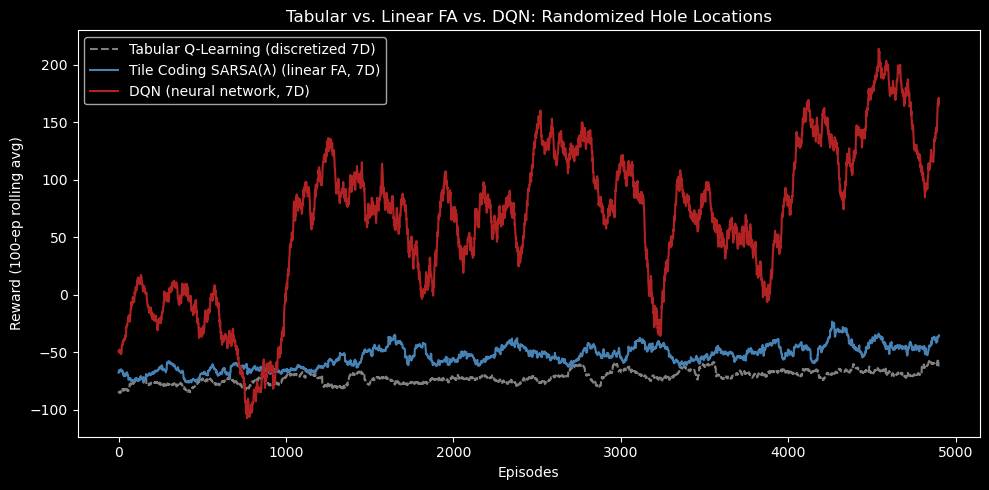

In [7]:
def train_dqn_random_holes(episodes=1000, batch_size=64):
    env = RosieMomentumRandomHolesEnv(); action_dim = len(env.action_space)
    policy_net = DQN(7, action_dim).float(); target_net = DQN(7, action_dim).float()
    target_net.load_state_dict(policy_net.state_dict()); target_net.eval()
    optimizer = optim.Adam(policy_net.parameters(), lr=1e-3); memory = ReplayBuffer(10000)
    epsilon, gamma = 1.0, 0.99; history = []
    for e in range(episodes):
        state = env.reset(); total_reward = 0
        while True:
            # Epsilon-greedy action selection
            if random.random() < epsilon: action = random.randint(0, action_dim-1)
            else:
                with torch.no_grad(): action = policy_net(torch.FloatTensor(state).unsqueeze(0)).argmax().item()
            
            # Step in environment and store experience
            next_s, reward, done = env.step(action); memory.push(state, action, reward, next_s, done)
            state, total_reward = next_s, total_reward + reward
            
            # Optimization step
            if len(memory) > batch_size:
                # Sample a random batch from replay buffer
                s_b, a_b, r_b, ns_b, d_b = memory.sample(batch_size)
                
                # Get current Q-values from policy network
                curr_q = policy_net(torch.FloatTensor(s_b)).gather(1, torch.LongTensor(a_b).unsqueeze(1))
                
                # Compute target Q-values using target network (Fixed Q-Targets)
                with torch.no_grad(): 
                    max_next_q = target_net(torch.FloatTensor(ns_b)).max(1)[0].unsqueeze(1)
                    target_q = torch.FloatTensor(r_b).unsqueeze(1) + (1 - torch.FloatTensor(d_b).unsqueeze(1)) * gamma * max_next_q
                
                # Minimize Mean Squared Error (MSE) loss
                loss = torch.nn.functional.mse_loss(curr_q, target_q)
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            
            if done: break
        epsilon = max(0.05, epsilon * 0.995); history.append(total_reward)
        # Periodically update the target network
        if e % 10 == 0: target_net.load_state_dict(policy_net.state_dict())
    return policy_net, history

dqn_rh_history = load_result('dqn_random_holes_history.pkl')
dqn_policy_rh = None
if dqn_rh_history is None:
    print("Training DQN on Randomized Holes...")
    dqn_policy_rh, dqn_rh_history = train_dqn_random_holes(episodes=1000)
    save_result(dqn_rh_history, 'dqn_random_holes_history.pkl')
    torch.save(dqn_policy_rh.state_dict(), os.path.join('saved_results', 'dqn_random_holes_weights.pth'))

# 3-way comparison: Tabular vs. Tile Coding vs. DQN
# Align all to the same episode count for a fair visual comparison
min_len = min(len(h_rh), len(h_rh_linear), len(dqn_rh_history))
smooth = lambda h: np.convolve(np.array(h[:min_len]), np.ones(100)/100, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(smooth(h_rh), label='Tabular Q-Learning (discretized 7D)', linestyle='--', color='gray')
plt.plot(smooth(h_rh_linear), label='Tile Coding SARSA(λ) (linear FA, 7D)', color='steelblue')
plt.plot(smooth(dqn_rh_history), label='DQN (neural network, 7D)', color='firebrick')
plt.title("Tabular vs. Linear FA vs. DQN: Randomized Hole Locations")
plt.xlabel("Episodes"); plt.ylabel("Reward (100-ep rolling avg)")
plt.legend(); plt.tight_layout(); plt.show()

### DQN Policy Visualization

The cell below loads the saved DQN weights and runs one episode inline, rendering Rosie's movement at each step. The DQN agent uses the full 7D state vector (position, velocity, water level, and relative hole distance) to choose actions greedily.

In [8]:
env_vis = RosieMomentumRandomHolesEnv()
action_dim_vis = len(env_vis.action_space)

# Load the trained DQN weights
dqn_vis = DQN(7, action_dim_vis).float()
weights_path = os.path.join('saved_results', 'dqn_random_holes_weights.pth')

if os.path.exists(weights_path):
    dqn_vis.load_state_dict(torch.load(weights_path, weights_only=True))
    dqn_vis.eval()
    print("Loaded DQN weights. Running greedy episode...")

    def dqn_policy_fn(state):
        with torch.no_grad():
            return dqn_vis(torch.FloatTensor(state).unsqueeze(0)).argmax().item()

    #env_vis.run_inline(policy_fn=dqn_policy_fn, max_steps=400)
    env_vis.run_gui(policy_fn=dqn_policy_fn)
else:
    print("DQN weights not found at:", weights_path)
    print("Run main_lecture.py first (or the DQN training cell above) to generate them.")

Loaded DQN weights. Running greedy episode...
